# Coursework Set Week 6

**Common remarks**:

* Deadline: Sunday at 23:59h for the week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Redmar van Sinderen
* Username: risinderen
* Student number: S6446248
* Group (AS1, etc.): As 1

-----

In [ ]:
totalpoints = currentpoints = 0

### Exploring a HI data cube (7 pt) <font color='red'><b>COURSEWORK</b></font>
   
* Download FITS image [ngc6946.fits](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/ngc6946.fits)
* Create a mosaic with 5 rows and 10 columns of channel maps for the Z indices ``range(1, 101, 2)``
* Remove axis labeling with Axes methods ``set_xticklabels([])`` and ``set_yticklabels([])``.
* If you add two channel maps you get a new map where each pixel is the sum of the two maps. If you add all channel maps (not the noisy ones), you get a so called *total HI* map.

    * Select a suitable range of channel maps and sum them to get a total HI map. Make a plot of this map
    * Label the axes with the header values of ``CTYPE1`` and ``CTYPE2``.
    * Make a locatable colorbar and label its Y axis with the header value of ``BUNIT``. 
        
* A *position velocity* (PV) map is a slice through the data at one fixed spatial position. 
   It tells you something about how the velocities in a galaxy behave as function of position 
   and one fixed position.   
   In NumPy jargon a PV map can be an YZ slice or a XZ slice. 

    * Plot a PV map for a fixed Right Ascension (R.A.) with index 50.
    * Plot a vertical line at Dec. with index 40.
    * Label the axes with the header values of ``CTYPE2`` and ``CTYPE3``. <br>&nbsp;</br>
        
* A *global HI spectral profile* is a slice in along the spectral axis at a fixed Right Ascension and Declination.
   It is a 1D curve with intensities as function of frequency (or velocity). It shows you at which 
   velocity most of the gas is rotating in a galaxy given a position in R.A. and Dec.

    * Plot a global profile at R.A. with index 50 and Dec. with index 40.
    * Label the plot axes with the header values of ``CTYPE3`` and ``BUNIT``. <br>&nbsp;</br>

* What is the relation between this profile and the vertical line in the previous plot of the PV diagram?   

**Answers**:

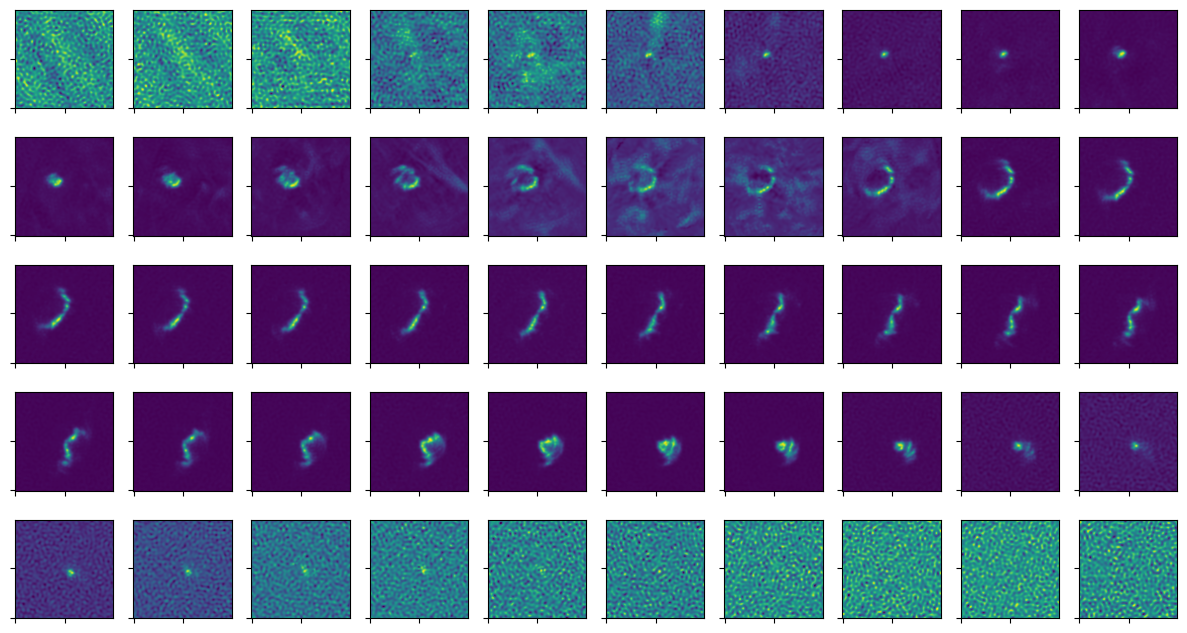

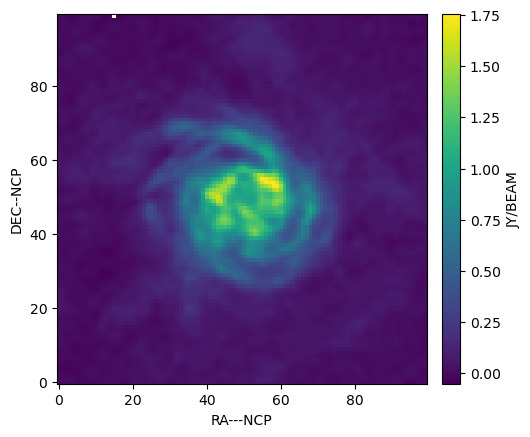

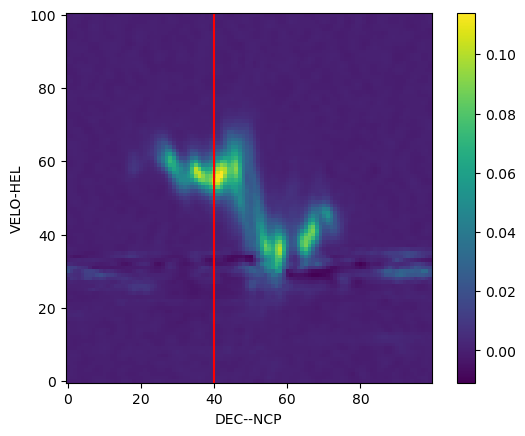

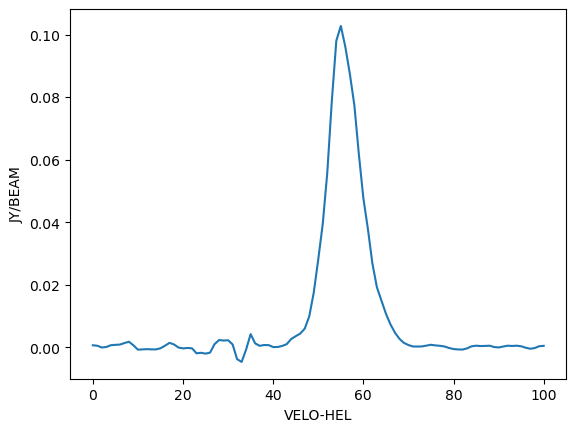

In [30]:
from astropy.io import fits
import numpy as np
import scipy as scp
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

#mosaic map
hdulist = fits.open('ngc6946.fits')       #opening the fits file
data = hdulist[0].data                    #taking out the data
header = hdulist[0].header

z_indices = list(range(1,101,2))          #the range of z indices and in a list to use for further applications


fig, axes = plt.subplots(5,10, figsize=(15,8))           #a total of 5 rows x 10 columns plots to make a mosaic

for ax, z in zip(axes.flatten(), z_indices):             #looping over the subplots by making the 5x10 into a 1x50 and then assigns what dataset is in each plot
    ax.imshow(data[z, :, :], origin='lower', cmap='viridis')          #plotting the data of each indice
    ax.set_xticklabels([])          #removing the x ticks
    ax.set_yticklabels([])          #removing the y ticks


plt.show()

#total HI map
hi_map = np.sum(data[14:80,:,:], axis = 0)          #summing the chosen data to appear as one image
fig, ax = plt.subplots()
img1 = ax.imshow(hi_map, origin='lower', cmap='viridis')
ax.set_xlabel(header.get('CTYPE1', 'X'))
ax.set_ylabel(header.get('CTYPE2', 'Y'))

devider = make_axes_locatable(ax)
cb = devider.append_axes("right", size= "5%", pad = 0.15)
cbar = fig.colorbar(img1,cax=cb)
cbar.set_label(header.get('BUNIT', 'Intensity'))

plt.show()


#PV map
pv_map = data[:, :, 50]         #slices the data at index 50 of R.A

fig, ax = plt.subplots()
im = ax.imshow(pv_map, origin='lower', cmap='viridis')

ax.axvline(40, color='red')       # Vertical line at Dec index 40

ax.set_xlabel(header.get('CTYPE2', 'Dec'))
ax.set_ylabel(header.get('CTYPE3', 'Velocity'))

plt.colorbar(im)
plt.show()

#global HI spectral profile
spectrum = data[:, 40, 50]

fig, ax = plt.subplots()
ax.plot(spectrum)

ax.set_xlabel(header.get('CTYPE3', 'Velocity'))
ax.set_ylabel(header.get('BUNIT', 'Intensity'))

plt.show()

print("The graph is just the visual representation of the intensity of the line in the figure")

In [ ]:
# Leave unaltered
totalpoints += 7
currentpoints += 0.0

### Galaxy Colour (5 pt) <font color='red'><b>COURSEWORK</b></font>
   
Download [SDSS_DR17_galaxies.fits](https://brightspace.rug.nl/content/enforced/457626-WBAS018-05.2025-2026.1/SDSS_DR17_galaxies.fits), which contains apparent magnitude in ``u, g, r, i, z`` five SDSS broad-band filters.

* Create a Pandas DataFrame from the FITS table.
* Filter out any data with negative values.
* Calculate every combination of colours from each broad band filter, e.g. u-g, u-r, u-i, u-z, g-r, ......
* Calculate the mean and standard deviation of the each colour.
* Use Object-Oriented Plotting to create a corner plot using derived colours.
* Set the xlim and ylim to be within three standard deviation.
* Add title for each histogram with information of the mean and standard deviation of each colour in the format of $\mu\pm\sigma$
 (to one decimal place).

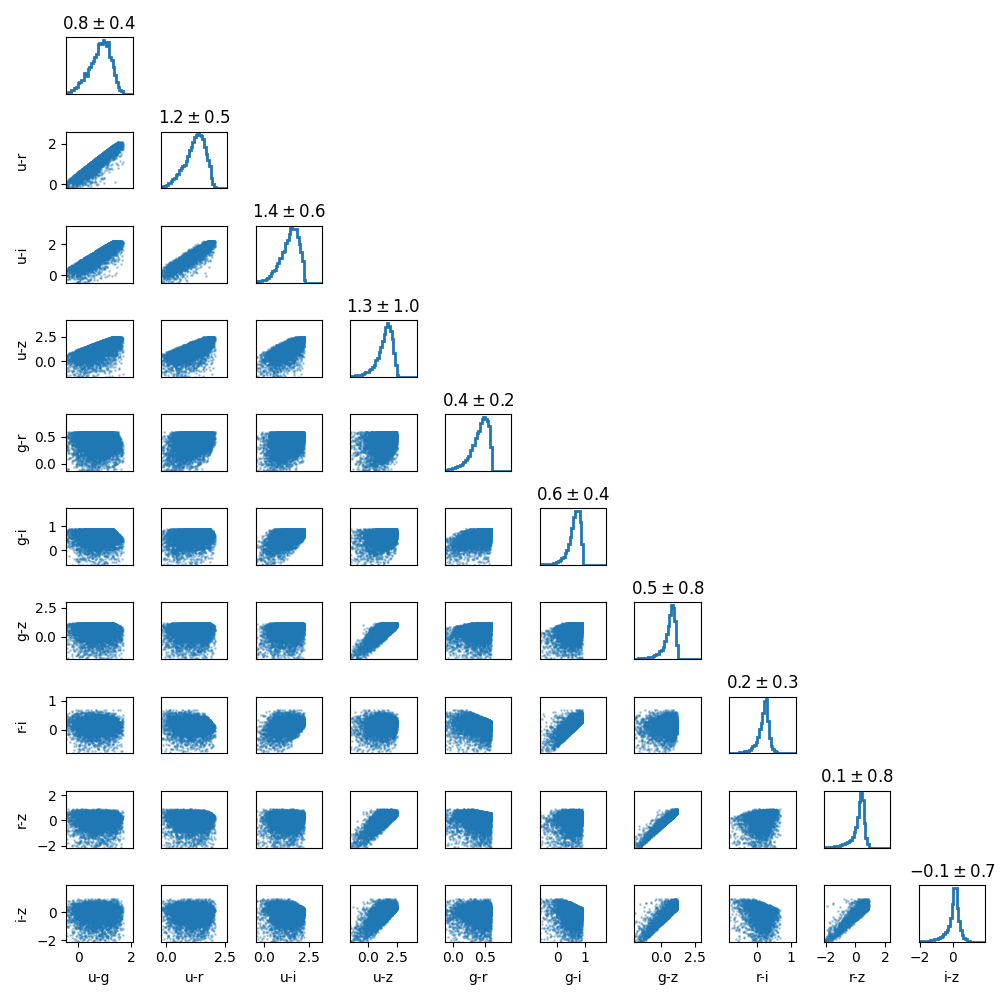
   
**Plot and answer**:

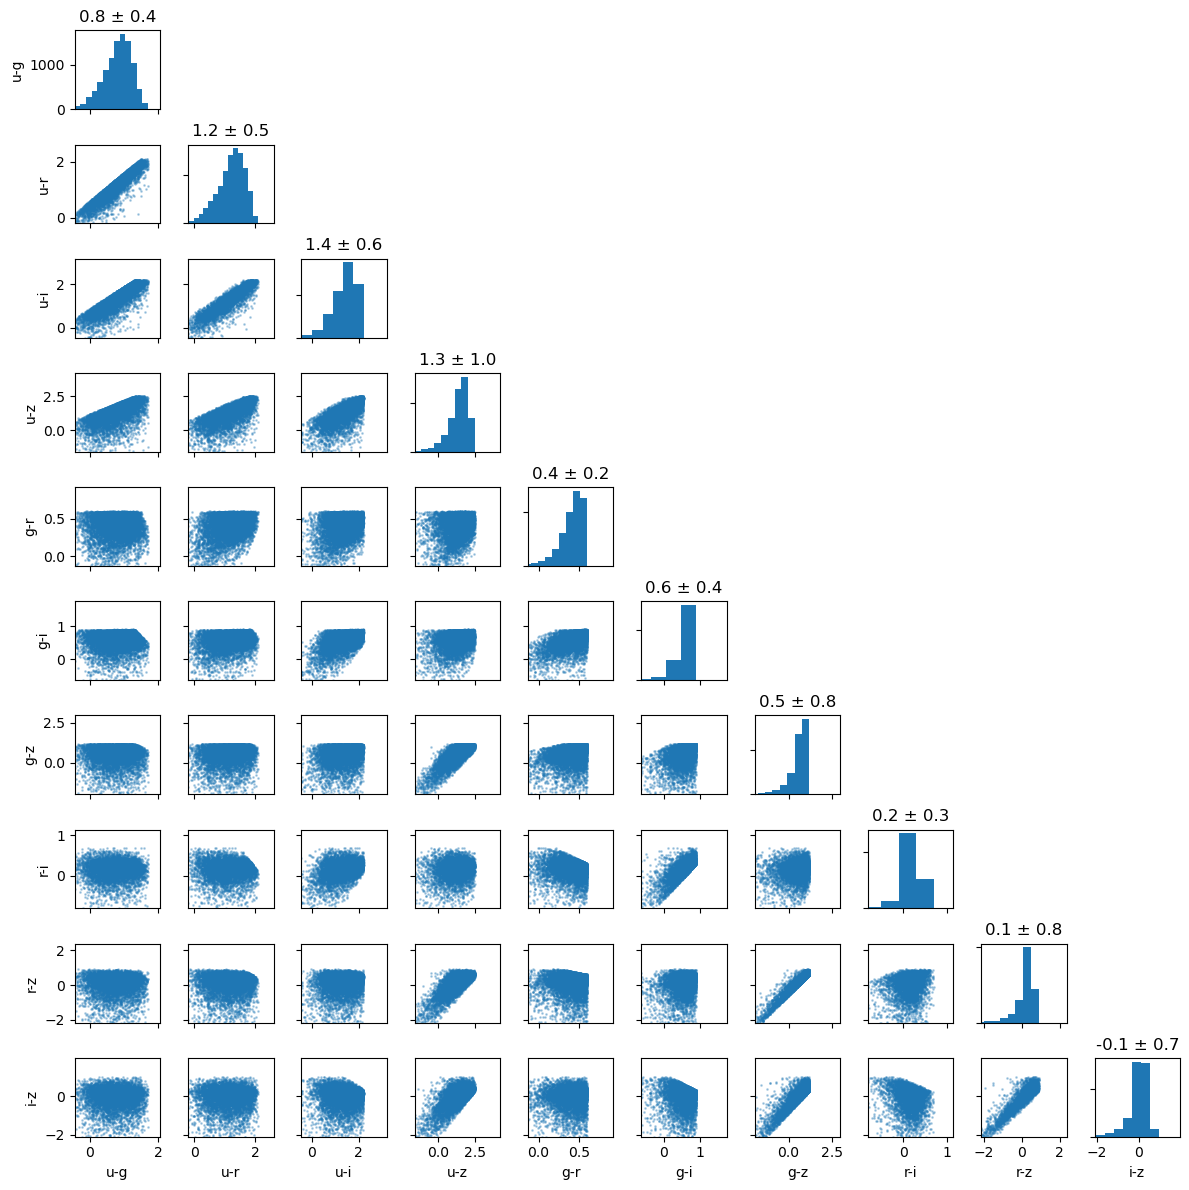

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table
import itertools


hdul = fits.open('SDSS_DR17_galaxies.fits')
data = hdul[1].data 

table = Table(data)
df = table.to_pandas()

filters = ['u', 'g', 'r', 'i', 'z']
df = df[filters]


df = df[(df > 0)]        # Remove negative values


color_pairs = list(itertools.combinations(filters, 2))               #gives all the possible combinations of 2 pairs, without repertition
colors = {}

for f1, f2 in color_pairs:         #calculates the actual values for said combinations
    name = f"{f1}-{f2}"
    colors[name] = df[f1] - df[f2]

color_df = pd.DataFrame(colors)

#std and mean
stats = {}
for col in color_df.columns:
    mean = color_df[col].mean()
    std = color_df[col].std()
    stats[col] = (mean, std)


#plot
cols = color_df.columns
n = len(cols)

fig, axes = plt.subplots(n, n, figsize=(12, 12))

for i in range(n):
    for j in range(n):
        ax = axes[i, j]

        if i < j:
            # Upper triangle -> empty
            ax.axis('off')
            continue

        if i == j:
            # Histogram
            col = cols[i]
            mean, std = stats[col]

            ax.hist(color_df[col], bins=30)
            ax.set_title(f"{mean:.1f} ± {std:.1f}")
            ax.set_xlim(mean - 3*std, mean + 3*std)

        else:
            x = cols[j]
            y = cols[i]

            ax.scatter(color_df[x], color_df[y], s=1, alpha=0.3)

            mx, sx = stats[x]
            my, sy = stats[y]

            ax.set_xlim(mx - 3*sx, mx + 3*sx)
            ax.set_ylim(my - 3*sy, my + 3*sy)

        #makes sure only the outer axis have values and not every single axis which would make it look like a mess
        if i < n-1:   
            ax.set_xticklabels([])
        if j > 0:
            ax.set_yticklabels([])

# Labels only on outer axes
for i in range(n):
    axes[-1, i].set_xlabel(cols[i])
    axes[i, 0].set_ylabel(cols[i])

plt.tight_layout()
plt.show()

In [ ]:
# Leave unaltered
totalpoints += 5
currentpoints += 0.0

### Astroquery: retrieving SDSS image and spectra (5 pt) <font color='red'><b>COURSEWORK</b></font>

Spiral galaxy M77 (NGC 1068) is a bright galaxy known for hosting an active galactic nucleus (AGN). With Astropy package, we construct M77's coordinate using the code below.

```python
from astropy import coordinates as coords

# Coordinates of M77
ra = 40.6696  # degrees
dec = -0.0133  # degrees
pos = coords.SkyCoord(ra, dec, unit="deg", frame="icrs")
```

* Use ``astroquery`` ([search regions](https://astroquery.readthedocs.io/en/latest/sdss/sdss.html#searching-regions-and-multiple-objects)) on the ``pos``, containing RA and DEC of this galaxy, to retrieve its SDSS spectrum using ``get_spectra()``. The search radius sets as ``10 arcsec`` for searching.
* The return object of ``get_spectra()`` is a list of [HDUList](https://docs.astropy.org/en/stable/io/fits/api/hdulists.html#astropy.io.fits.HDUList) objects.
* Retrieve flux and wavelengths using columns ``flux`` and ``loglam``. Note that the wavelength is in logarithmic value, you need to convert it back to a linear scale.
* The redshift of M77 is approximately ``z~0.0038``. Calculating the rest-frame wavelengths.
* Use Object-Oriented Plotting to plot:
    * a rest-frame spectrum which corrects the redshift effect (top)
    * a zoom-in spectrum at wavelength between 6450 and 6650 angstrom (bottom)
* Draw vertical lines for H$\alpha$ lines in both frames. Label them and show with legend.
* Draw vertical lines indicating approximately where the peak of the flux is, which in fact should be the H$\alpha$ line.
* An example plot is shown below.
* Calculating the velocity indicated by the difference between the two wavelengths.
* Share your thought using a markdown on what might be causing this offset. This question will not be graded, and meant to train a bit your scientific thinking. Feel free to express any thought.

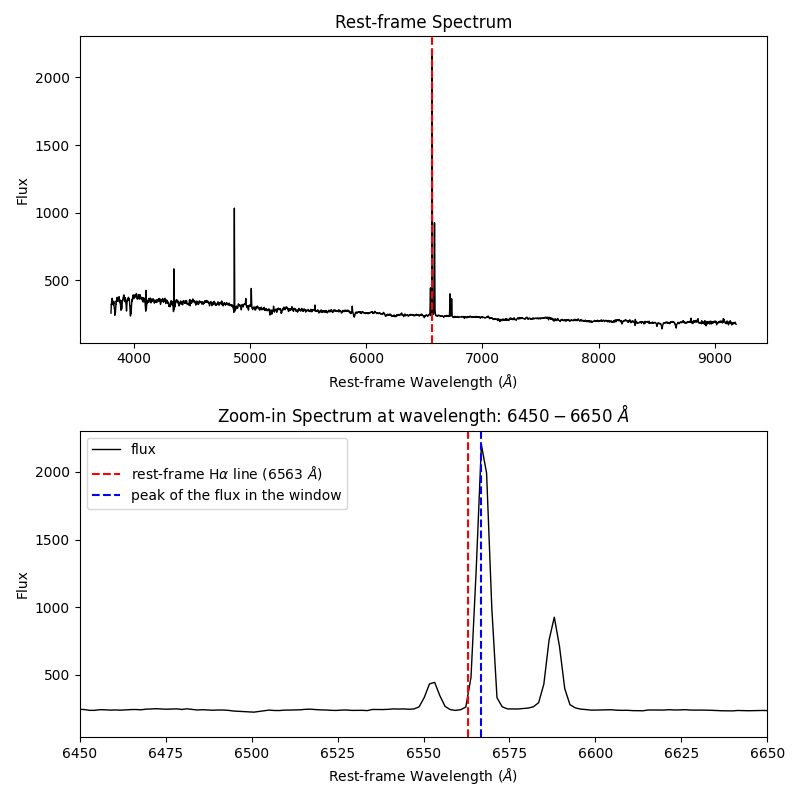

### NOTE
for some reason when i ran this at home it couldnt query the data for some reason so i dont know whats going on. The query is timing out for some reason i think but idk why or what is happening. In the first place it would say that it didnt even recognised astroquery as a module. To fix this i changed the kernel type to anaconda3 (2024) and that seemed to fix the issue with it not recognising the module but i have no clue why its not querying. Someone else has the same query as i do and there its working but for me its not. due to this there might be some more mistakes because i couldnt test the code. Would it be possible if you looked into this to fix this?

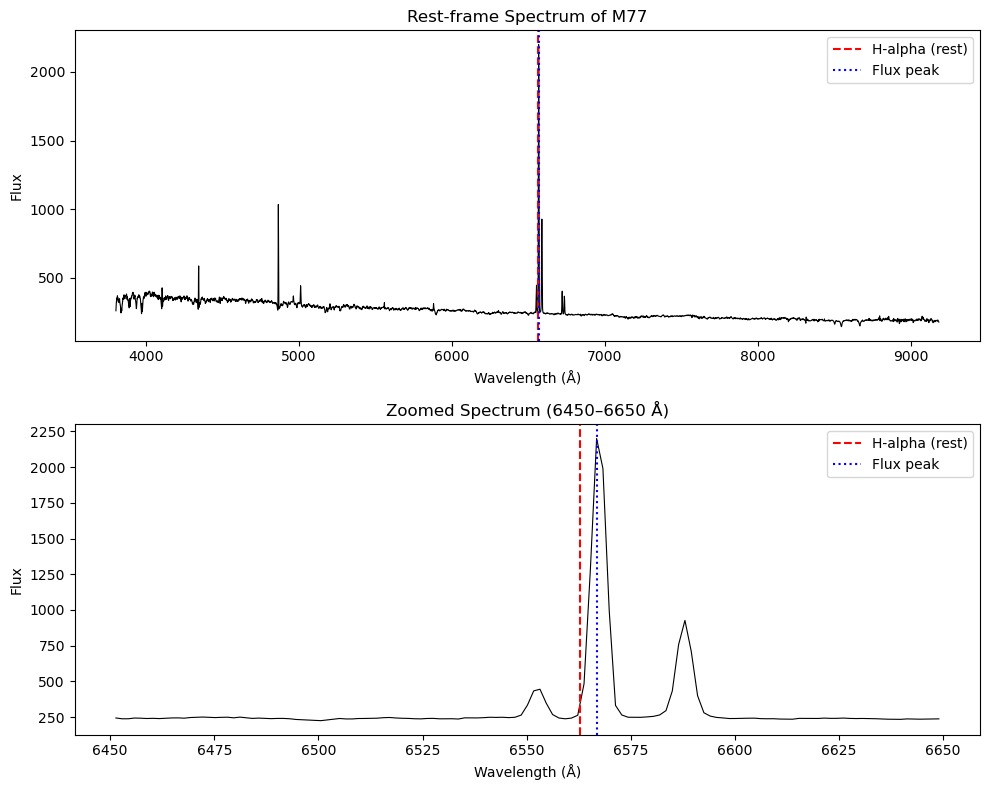

Velocity ≈ 182.17 km/s


In [2]:
from astroquery.sdss import SDSS
from astropy import coordinates as coords
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt

# Coordinates of M77
ra = 40.6696
dec = -0.0133
pos = coords.SkyCoord(ra, dec, unit="deg", frame="icrs")

# Search spectra within 10 arcsec
query = SDSS.query_region(pos, radius=10*u.arcsec, spectro=True)
spec = SDSS.get_spectra(matches=query)

# Take the first spectrum
hdul = spec[0]
data = hdul[1].data


flux = data['flux']
loglam = data['loglam']

# Convert log wavelength → linear wavelength (Angstrom)
wavelength = 10**loglam

z = 0.0038

# Rest-frame wavelength
rest_wavelength = wavelength / (1 + z)

# H-alpha rest wavelength (Angstrom)
H_alpha = 6562.8

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

#Top: Full rest-frame spectrum 
ax1.plot(rest_wavelength, flux, color='black', lw=0.8)

# H-alpha line
ax1.axvline(H_alpha, color='red', linestyle='--', label='H-alpha (rest)')

# Find peak
peak_idx = np.argmax(flux)
peak_wave = rest_wavelength[peak_idx]
ax1.axvline(peak_wave, color='blue', linestyle=':', label='Flux peak')

ax1.set_title("Rest-frame Spectrum of M77")
ax1.set_xlabel("Wavelength (Å)")
ax1.set_ylabel("Flux")
ax1.legend()

# Bottom: Zoomed region 
mask = (rest_wavelength > 6450) & (rest_wavelength < 6650)        #checks if the restwavelength is between 6450 and 6650

ax2.plot(rest_wavelength[mask], flux[mask], color='black', lw=0.8)

# H-alpha line
ax2.axvline(H_alpha, color='red', linestyle='--', label='H-alpha (rest)')
ax2.axvline(peak_wave, color='blue', linestyle=':', label='Flux peak')

ax2.set_title("Zoomed Spectrum (6450–6650 Å)")
ax2.set_xlabel("Wavelength (Å)")
ax2.set_ylabel("Flux")
ax2.legend()

plt.tight_layout()
plt.show()

c = 3e5        # km/s

delta_lambda = peak_wave - H_alpha
velocity = c * (delta_lambda / H_alpha)

print(f"Velocity ≈ {velocity:.2f} km/s")

In [ ]:
# Leave unaltered
totalpoints += 5
currentpoints += 0.0

### Comparing an image in different color scales (stretches) (4pt) <font color='red'><b>COURSEWORK</b></font>

Given is the Blaauw observatory FITS file
[20210422_Li_.00000066.FIT](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/20210422_Li_.00000066.FIT)

Use the `imdisplay()` function from the notebook *The art of plotting an image* to make a mosaic with this image using all the different scales (stretches) available to that function. 

* Add a proper docstring to the function.
* Show the used scale in the title of the plot. (hints: tight_layout, fontsize).
* Also include the image without scaling as the first plot in the mosaic.

**Answer**:

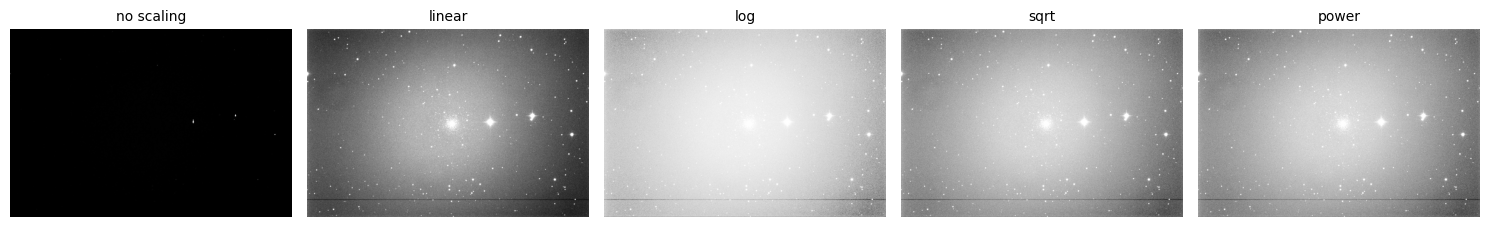

In [44]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits

def imdisplay(ax, image, scale='linear', vmin=None, vmax=None):
    """
    Display an astronomical image on a given matplotlib axis with different intensity scalings.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        The axis on which the image will be displayed.

    image : 2D numpy.ndarray
        The image data array (e.g., from a FITS file).

    scale : str, optional
        The scaling/stretch to apply to the image. Options include:
        'linear', 'log', 'sqrt', 'power'.
        Default is 'linear'.

    vmin, vmax : float, optional
        Minimum and maximum values for normalization. If None, they are
        determined from the image percentiles.

    Notes
    -----
    This function applies different intensity transformations to enhance
    visibility of faint or bright structures in astronomical images.
    """



    # Default normalization
    if vmin is None or vmax is None:
        vmin, vmax = np.percentile(image, [1, 99])

    img = np.clip(image, vmin, vmax)

    # Apply scaling
    if scale == 'linear':
        scaled = img
    elif scale == 'log':
        scaled = np.log10(img - vmin + 1)
    elif scale == 'sqrt':
        scaled = np.sqrt(img - vmin)
    elif scale == 'power':
        scaled = (img - vmin) ** 0.5
    else:
        raise ValueError(f"Unknown scale: {scale}")

    ax.imshow(scaled, origin='lower', cmap='gray')
    ax.set_title(scale, fontsize=10)
    ax.axis('off')



filename = "20210422_Li_.00000066.FIT"
hdul = fits.open(filename)
image = hdul[0].data
hdul.close()

scales = ['none', 'linear', 'log', 'sqrt', 'power']

fig, axes = plt.subplots(1, len(scales), figsize=(15, 4))

for ax, scale in zip(axes, scales):
    if scale == 'none':
        ax.imshow(image, origin='lower', cmap='gray')
        ax.set_title("no scaling", fontsize=10)
        ax.axis('off')
    else:
        imdisplay(ax, image, scale=scale)

plt.tight_layout()
plt.show()

In [ ]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Image stacking optical data (6pt) <font color='red'><b>COURSEWORK</b></font>

Select one of the suitable observations from the next table or
find one yourself in the
[Blaauw Observatory Overview](https://www.astro.rug.nl/intranet/sterrenwacht/files.py)

* Following the stacking procedure in the notebook about image stacking for the data you selected. Show the result.
* Align the images and repeat the stacking procedure. Show the result.
* Remove all unnecessary code and markdown text.
* Include code and result in your report.

| nr | Folder on data server |
| :---  | :---: |
| 2  | ``/net/dataserver3/data/users/sterrenwacht/images/210418/STL-6303E/i/`` |
| 3  | ``/net/dataserver3/data/users/sterrenwacht/images/190515/STL-6303E/i/`` |
| 4  | ``/net/dataserver3/data/users/sterrenwacht/images/190428/STL-6303E/i/`` |
| 5  | ``/net/dataserver3/data/users/sterrenwacht/images/190419/STL-6303E/i/`` |
| 6  | ``/net/dataserver3/data/users/sterrenwacht/images/180504/STL-6303E/i/`` |
| 7  | ``/net/dataserver3/data/users/sterrenwacht/images/160913/STL-6303E/i/`` |
| 8  | ``/net/dataserver3/data/users/sterrenwacht/images/140912/STL-6303E/i/`` |
| 9  | ``/net/dataserver3/data/users/sterrenwacht/images/131001/STL-6303E/i/`` |
| 10 | ``/net/dataserver3/data/users/sterrenwacht/images/101212/STL-6303E/i/`` |

**Code and plot**:

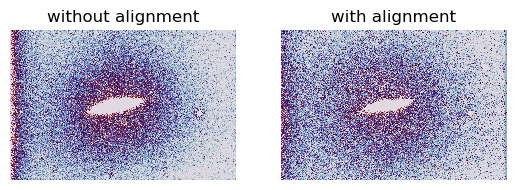

In [29]:
from astropy.visualization import ImageNormalize
from astropy.visualization import SinhStretch, AsymmetricPercentileInterval, LinearStretch,\
                                  LogStretch, PowerStretch, SqrtStretch, SquaredStretch,\
                                  HistEqStretch, ZScaleInterval
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import astroalign as aa

def imdisplay(data,
              ax,
              vmin=None, vmax=None,
              percentlow=1, percenthigh=99,
              zscale=False,
              scale='linear',
              power=1.5,
              cmap='gray',
              **kwargs):
    if zscale:
        # Always overwrite vmin and vmax
        interval = ZScaleInterval()
        vmin, vmax = interval.get_limits(data)
    if vmin is None or vmax is None:
        interval = AsymmetricPercentileInterval(percentlow, percenthigh)
        vmin2, vmax2 = interval.get_limits(data)
        if vmin is None:
            vmin = vmin2
        if vmax is None:
            vmax = vmax2

    if scale == 'linear':
        stretch = LinearStretch(slope=0.5, intercept=0.5)
    if scale == 'sinh':
        stretch = SinhStretch()
    if scale == 'log':
        stretch = LogStretch()
    if scale == 'power':
        stretch = PowerStretch(power)
    if scale == 'sqrt':
        stretch = SqrtStretch()
    if scale == 'squared':
        stretch = SquaredStretch()
    if scale == 'hist':
        stretch = HistEqStretch(data)  # Needs argument data and data min, max for vmin, vmax
        vmin = data.min(); vmax = data.max()

    norm = ImageNormalize(vmin=vmin, vmax=vmax, stretch=stretch)
    return ax.imshow(data, interpolation='none', origin='lower', norm=norm, cmap=cmap, **kwargs)

datadir = "/net/dataserver3/data/users/sterrenwacht/images/180504/STL-6303E/i/"
excludes = ['BIAS', 'FLAT', 'DARK']  # Exclude these images if these are opart of the file name
path = Path(datadir)
filepaths = []
for filepath in path.iterdir():
    if filepath.suffix.lower() in ['.fits', '.fit', '.fts']:         #makes sure that the correct file types are chosen
        if not any(ext in filepath.name for ext in excludes):
            filepaths.append(filepath)
images = []
#taking out the data
for f in filepaths:
    hdul = fits.open(f)
    images.append(hdul[0].data.astype(float))      
    hdul.close()

datacube = np.stack(images)      #making it a datcube
stacked_images = np.median(datacube, axis=0)        #stacking the images in 1 axis

fig, ax = plt.subplots(1,2)
imdisplay(stacked_images, ax[0], percentlow=5, percenthigh=95, scale='squared', cmap='twilight')
ax[0].axis('off')
ax[0].set_title("without alignment")

target = images[16]
aligned_images=[]
for im in images:
    try:
        aligned_im, footprint = aa.register(im, target, detection_sigma=5.0)       #does magic (aligns them with respect to a certain image)
        aligned_images.append(aligned_im)
    except:
        pass
        
cubedaligned = np.stack(aligned_images)
stack_aligned = np.median(cubedaligned,axis=0)
imdisplay(stack_aligned, ax[1], percentlow=5, percenthigh=95, scale = 'squared', cmap='twilight')
ax[1].axis('off')
ax[1].set_title("with alignment")

plt.show()

In [ ]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [ ]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")